# Лабораторная работа №1  
## Анализ и прогнозирование временных рядов на примере розничных продаж

**Исходные данные:** `retail_sales_mock_data.csv`  
**Что покрывает ноутбук:** все требования пункта 2 задания:
- EDA временного ряда;
- декомпозиция тремя подходами: классическая, FFT, wavelet;
- подбор и обучение моделей ARIMA и SARIMAX;
- оценка качества по MSE, R², AIC, BIC;
- анализ остатков;
- аналитические выводы после каждого крупного этапа.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import jarque_bera
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

import pywt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True


## 1. Загрузка и подготовка данных

In [3]:
DATA_PATH = "retail_sales_mock_data.csv"

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")
df = df.asfreq("MS")

display(df.head())
display(df.info())
display(df.describe().T)


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


<class 'pandas.DataFrame'>
DatetimeIndex: 48 entries, 2020-01-01 to 2023-12-01
Freq: MS
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalesAmount   48 non-null     int64
 1   Promotion     48 non-null     int64
 2   HolidayMonth  48 non-null     int64
dtypes: int64(3)
memory usage: 1.5 KB


None

,count,mean,std,min,25%,50%,75%,max
SalesAmount,48.0,11768.541667,2257.544863,7783.0,10219.75,11851.0,13014.0,17996.0
Promotion,48.0,0.125000,0.334219,0.0,0.00,0.0,0.0,1.0
HolidayMonth,48.0,0.083333,0.279310,0.0,0.00,0.0,0.0,1.0


In [4]:
# Проверка пропусков и базовой структуры
print("Период наблюдений:", df.index.min().date(), "—", df.index.max().date())
print("Количество наблюдений:", len(df))
print("\nПропуски:")
display(df.isna().sum().to_frame("missing_count"))


Период наблюдений: 2020-01-01 — 2023-12-01
Количество наблюдений: 48

Пропуски:


,missing_count
SalesAmount,0
Promotion,0
HolidayMonth,0


## 2.1. Разведочный анализ данных (EDA)

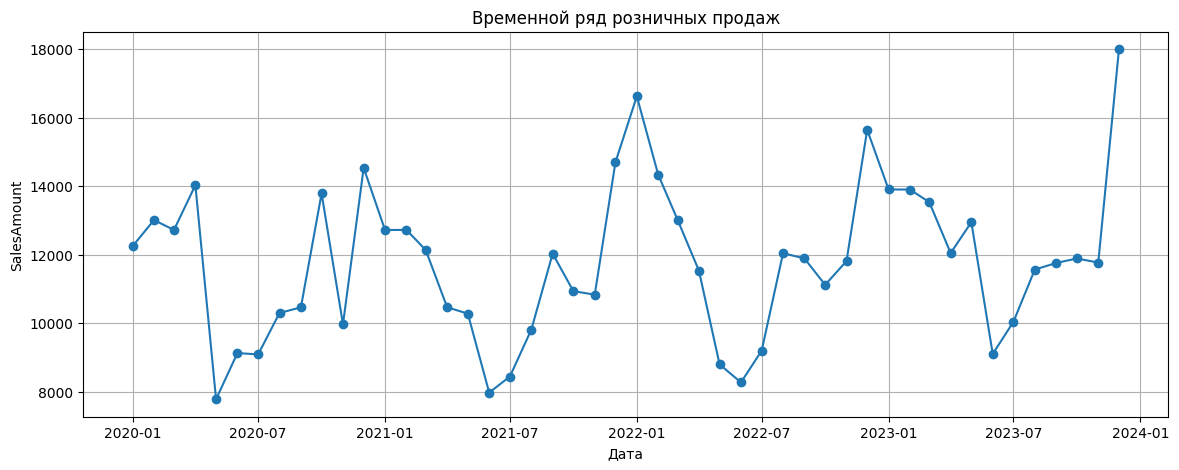

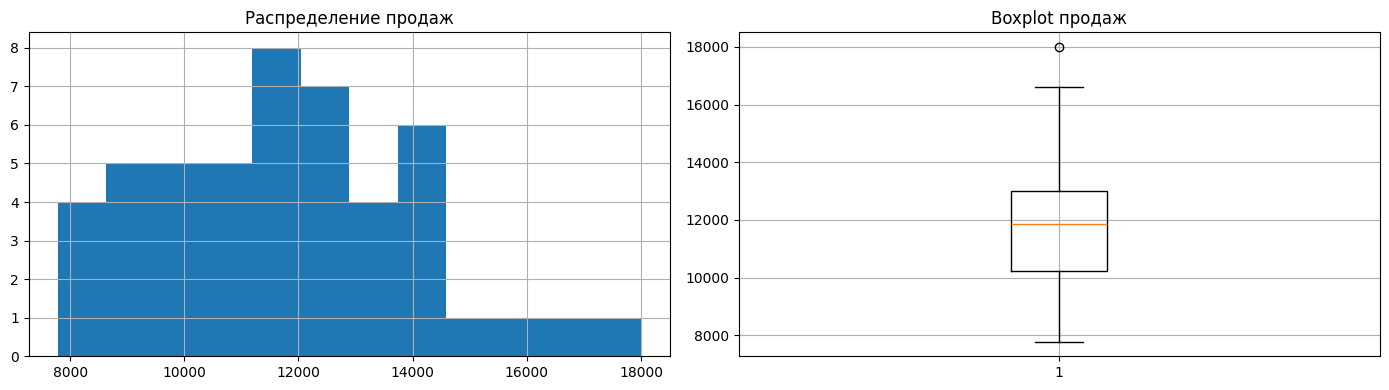

In [5]:
# Основной ряд и признаки
y = df["SalesAmount"]
exog = df[["Promotion", "HolidayMonth"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y, marker="o")
ax.set_title("Временной ряд розничных продаж")
ax.set_xlabel("Дата")
ax.set_ylabel("SalesAmount")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y, bins=12)
axes[0].set_title("Распределение продаж")
axes[1].boxplot(y, vert=True)
axes[1].set_title("Boxplot продаж")
plt.tight_layout()
plt.show()


,mean,sum
Year,,
2020,11422.250000,137067
2021,11088.000000,133056
2022,12025.333333,144304
2023,12538.583333,150463


,mean,median,std
Month,,,
1,13873.75,13312.0,1960.74
2,13493.00,13456.0,752.95
3,12853.75,12872.5,584.21
4,12020.75,11792.5,1492.52
5,9952.75,9539.5,2245.04
6,8621.00,8688.5,586.09
7,9193.75,9144.0,656.04
8,10929.75,10933.0,1047.94
9,11536.50,11825.5,723.57


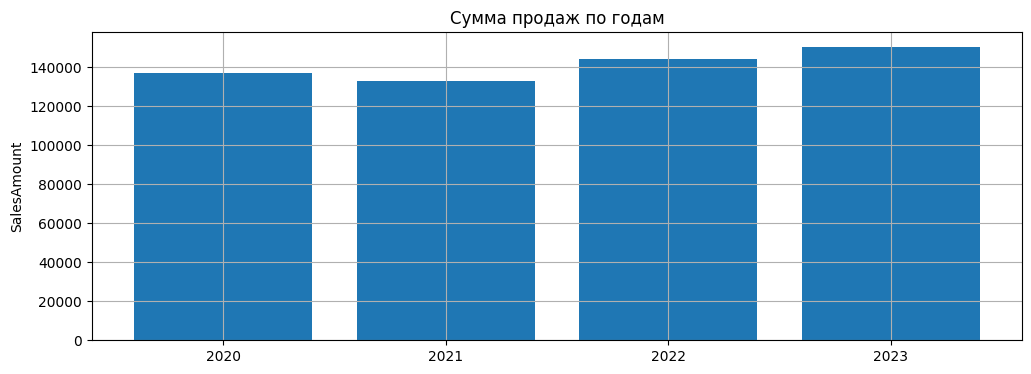

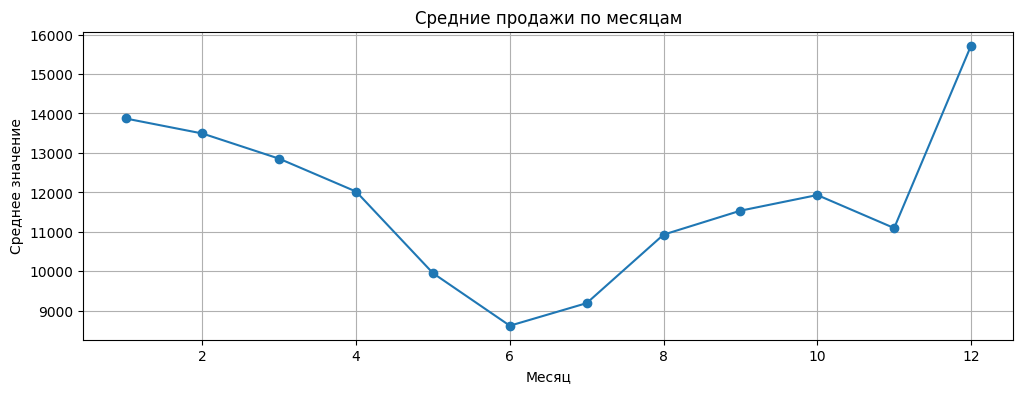

In [6]:
# Годовая и месячная агрегация
yearly = df.assign(Year=df.index.year).groupby("Year")["SalesAmount"].agg(["mean", "sum"])
monthly_pattern = df.assign(Month=df.index.month).groupby("Month")["SalesAmount"].agg(["mean", "median", "std"])

display(yearly)
display(monthly_pattern.round(2))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(yearly.index.astype(str), yearly["sum"])
ax.set_title("Сумма продаж по годам")
ax.set_ylabel("SalesAmount")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_pattern.index, monthly_pattern["mean"], marker="o")
ax.set_title("Средние продажи по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Среднее значение")
plt.show()


,count,mean,median
Promotion,,,
0,42,11621.238095,11791.0
1,6,12799.666667,13367.5


,count,mean,median
HolidayMonth,,,
0,44,11409.522727,11764.5
1,4,15717.750000,15170.5


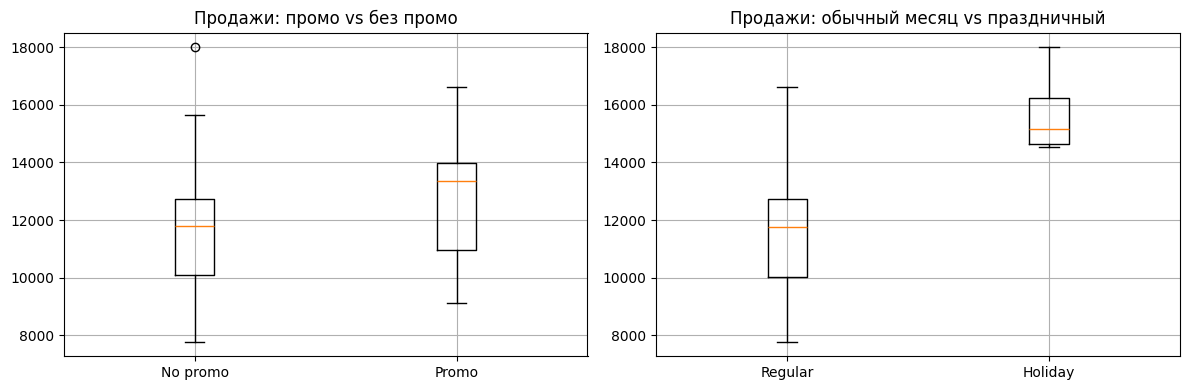

In [7]:
# Влияние промо и праздничного месяца
promo_stats = df.groupby("Promotion")["SalesAmount"].agg(["count", "mean", "median"])
holiday_stats = df.groupby("HolidayMonth")["SalesAmount"].agg(["count", "mean", "median"])

display(promo_stats)
display(holiday_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot([df.loc[df["Promotion"] == 0, "SalesAmount"],
                 df.loc[df["Promotion"] == 1, "SalesAmount"]],
                tick_labels=["No promo", "Promo"])
axes[0].set_title("Продажи: промо vs без промо")

axes[1].boxplot([df.loc[df["HolidayMonth"] == 0, "SalesAmount"],
                 df.loc[df["HolidayMonth"] == 1, "SalesAmount"]],
                tick_labels=["Regular", "Holiday"])
axes[1].set_title("Продажи: обычный месяц vs праздничный")
plt.tight_layout()
plt.show()


ADF statistic: -4.5142
p-value: 0.000185
Critical values: {'1%': np.float64(-3.5966), '5%': np.float64(-2.9333), '10%': np.float64(-2.605)}


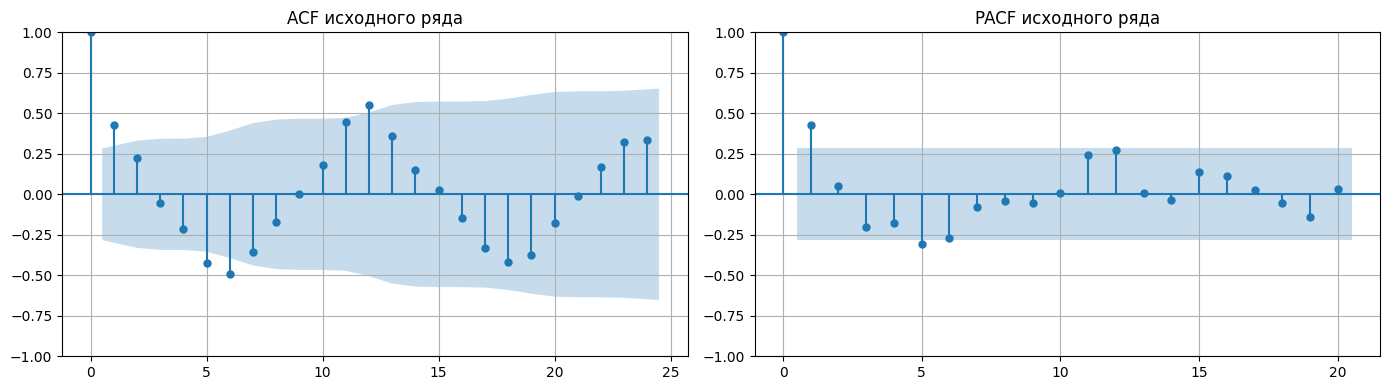

In [8]:
# Проверка стационарности и автокорреляции
adf_stat, adf_pvalue, _, _, crit_values, _ = adfuller(y)

print("ADF statistic:", round(adf_stat, 4))
print("p-value:", round(adf_pvalue, 6))
print("Critical values:", {k: round(v, 4) for k, v in crit_values.items()})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y, lags=24, ax=axes[0])
plot_pacf(y, lags=20, ax=axes[1], method="ywm")
axes[0].set_title("ACF исходного ряда")
axes[1].set_title("PACF исходного ряда")
plt.tight_layout()
plt.show()


### Вывод по этапу 2.1

1. Временной ряд **месячный**, содержит **48 наблюдений** за период с января 2020 по декабрь 2023.
2. По графикам видна **выраженная сезонность**: провал в конце весны / летом и рост ближе к концу года, особенно в декабре.
3. Праздничный месяц (`HolidayMonth=1`) заметно поднимает продажи, а промо-акции тоже влияют на уровень ряда, поэтому их разумно использовать как **экзогенные признаки** в SARIMAX.
4. ACF/PACF и сезонный рисунок указывают на наличие **годовой сезонности с периодом 12**, что делает сезонную модель более уместной, чем простую несезонную ARIMA.


## 2.1. Декомпозиция временного ряда

### 2.1.1. Классическая декомпозиция: additive / multiplicative / STL

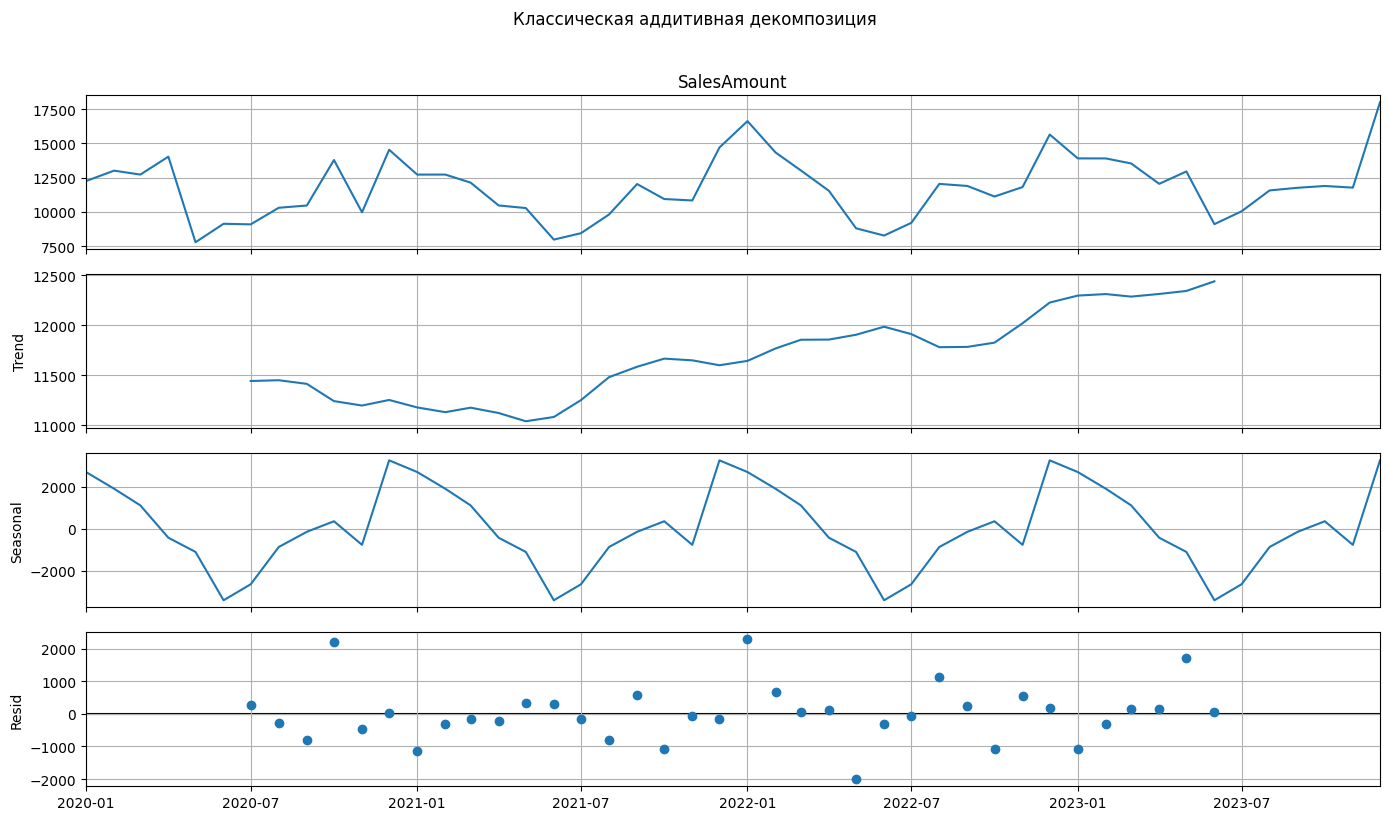

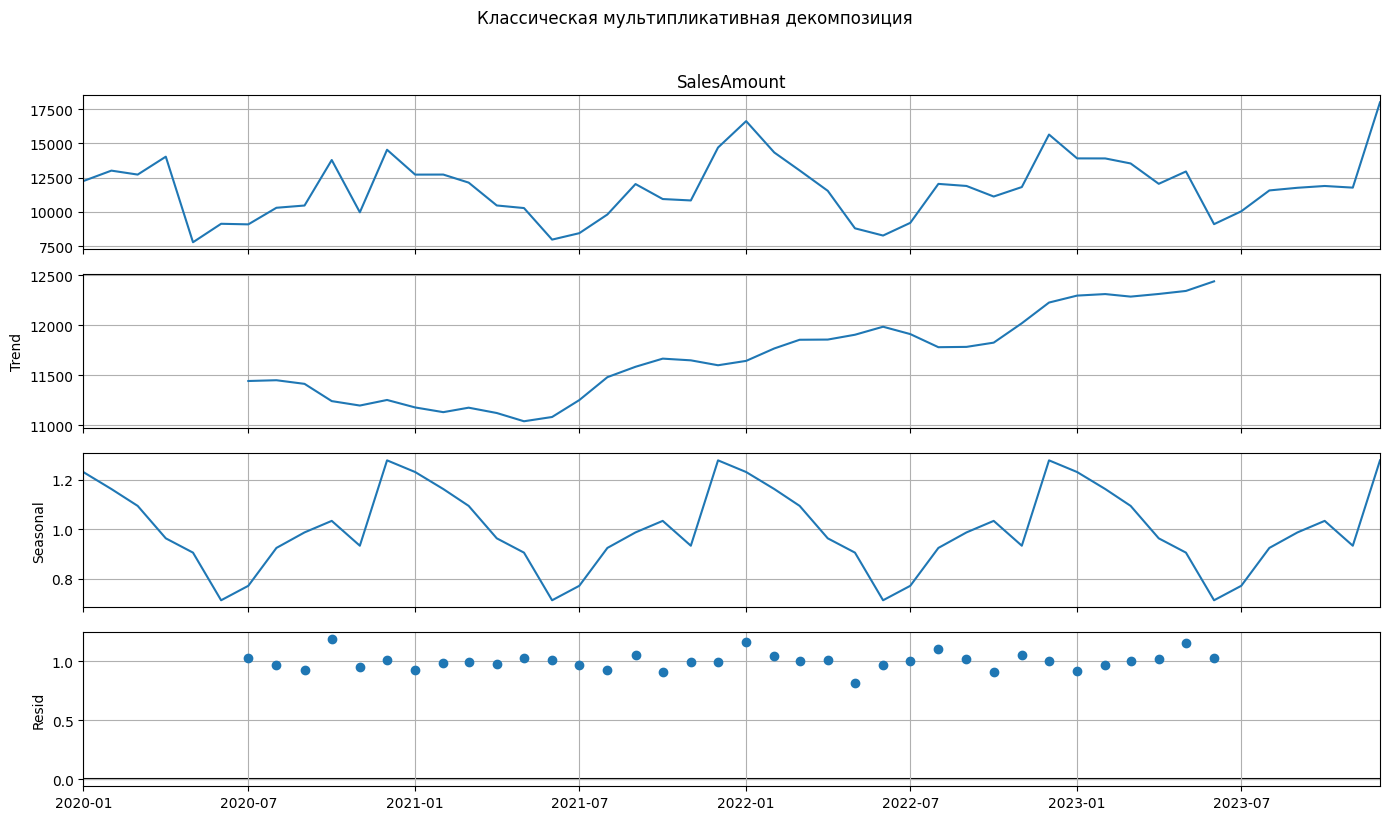

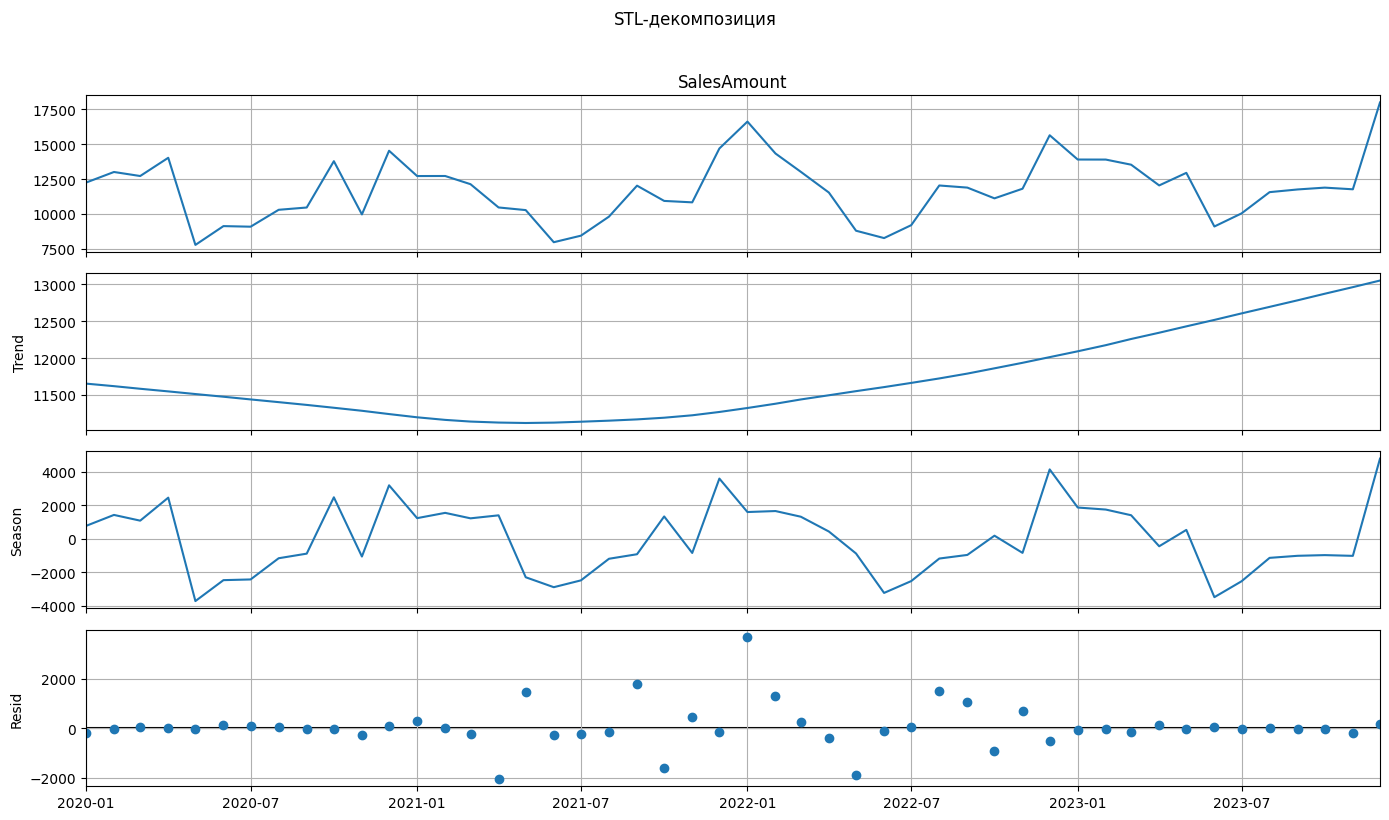

In [9]:
decomp_add = seasonal_decompose(y, model="additive", period=12)
decomp_mul = seasonal_decompose(y, model="multiplicative", period=12)
decomp_stl = STL(y, period=12, robust=True).fit()

fig = decomp_add.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Классическая аддитивная декомпозиция", y=1.02)
plt.tight_layout()
plt.show()

fig = decomp_mul.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Классическая мультипликативная декомпозиция", y=1.02)
plt.tight_layout()
plt.show()

fig = decomp_stl.plot()
fig.set_size_inches(14, 8)
fig.suptitle("STL-декомпозиция", y=1.02)
plt.tight_layout()
plt.show()


### 2.1.2. Спектральный анализ (FFT)

,frequency,amplitude,period_months
4,0.083,57678.597,12.000
12,0.250,20504.205,4.000
24,0.500,16836.000,2.000
1,0.021,14794.640,48.000
20,0.417,13539.812,2.400
23,0.479,13082.050,2.087
22,0.458,12407.895,2.182
8,0.167,12263.057,6.000
13,0.271,12236.138,3.692
14,0.292,11466.966,3.429


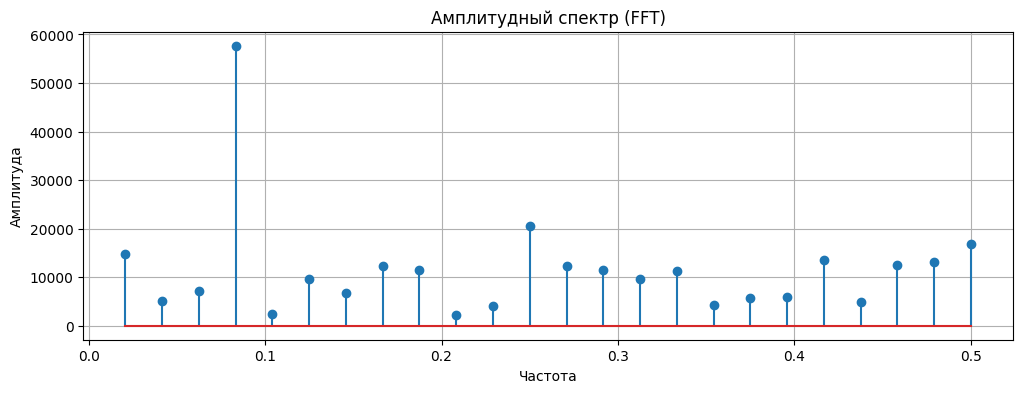

In [10]:
# FFT удобен для поиска доминирующих циклов в ряду.
signal = y.values
n = len(signal)
fft_vals = np.fft.rfft(signal - signal.mean())
fft_freq = np.fft.rfftfreq(n, d=1)  # 1 шаг = 1 месяц
fft_power = np.abs(fft_vals)

fft_df = pd.DataFrame({
    "frequency": fft_freq,
    "amplitude": fft_power
})

# Исключим нулевую частоту и оценим период как 1 / frequency
fft_nonzero = fft_df[fft_df["frequency"] > 0].copy()
fft_nonzero["period_months"] = 1 / fft_nonzero["frequency"]
fft_top = fft_nonzero.sort_values("amplitude", ascending=False).head(10)

display(fft_top.round(3))

fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(fft_nonzero["frequency"], fft_nonzero["amplitude"])
ax.set_title("Амплитудный спектр (FFT)")
ax.set_xlabel("Частота")
ax.set_ylabel("Амплитуда")
plt.show()


### 2.1.3. Вейвлет-анализ

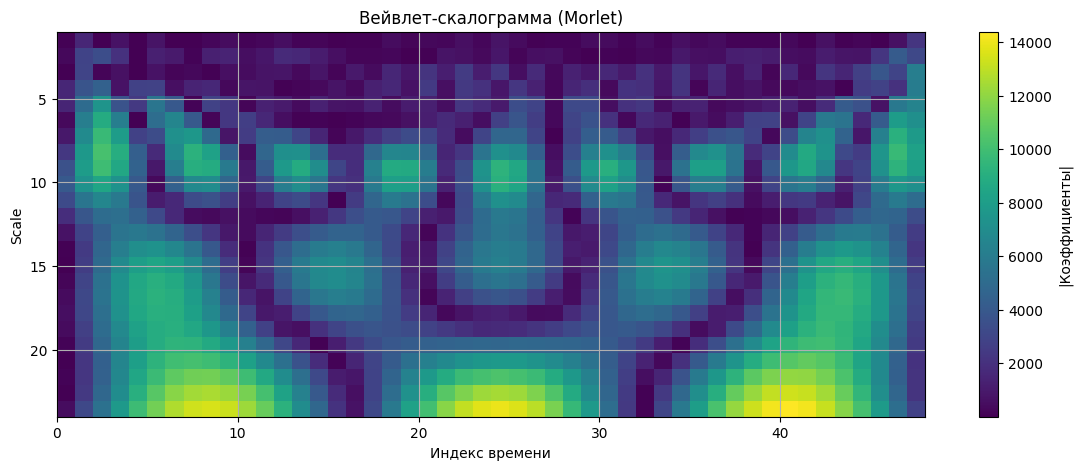

In [11]:
# Для вейвлет-анализа используем непрерывное вейвлет-преобразование (Morlet).
scales = np.arange(1, 25)
coefficients, frequencies = pywt.cwt(y.values, scales=scales, wavelet="morl")

plt.figure(figsize=(14, 5))
plt.imshow(
    np.abs(coefficients),
    extent=[0, len(y), scales.max(), scales.min()],
    aspect="auto"
)
plt.colorbar(label="|Коэффициенты|")
plt.title("Вейвлет-скалограмма (Morlet)")
plt.xlabel("Индекс времени")
plt.ylabel("Scale")
plt.show()


### Сравнение методов декомпозиции

**Классическая декомпозиция и STL**
- Хорошо показывают разложение на тренд, сезонность и остаток.
- Просты для интерпретации.
- STL обычно устойчивее к локальным выбросам и неидеальной сезонности.
- Ограничение: предполагают относительно стабильную структуру сезонности.

**FFT**
- Очень удобен для поиска доминирующих периодов.
- Помогает подтвердить наличие сезонности около 12 месяцев.
- Ограничение: не показывает, **когда именно** локально меняется структура сигнала; работает в частотной области, а не во времени.

**Вейвлет-анализ**
- Позволяет увидеть одновременно **время + масштаб/частоту**, то есть где усиливаются или ослабевают колебания.
- Особенно полезен, если сезонность и амплитуда меняются по времени.
- Ограничение: интерпретация сложнее, чем у классической декомпозиции и FFT.

### Вывод по этапу декомпозиции

Все три подхода подтверждают выраженную сезонную структуру ряда.  
Для интерпретации компонентов наиболее удобна **STL**, для поиска периодичности — **FFT**, а для анализа локальных изменений структуры — **wavelet**.  
Для дальнейшего моделирования это означает, что в прогнозной модели стоит учитывать **сезонность 12 месяцев** и внешние факторы (`Promotion`, `HolidayMonth`).


## 2.2. Построение прогнозных моделей

In [12]:
# Разделим данные на train/test:
# последние 12 месяцев оставим для проверки качества прогноза.
train = y.iloc[:-12]
test = y.iloc[-12:]

train_exog = exog.iloc[:-12]
test_exog = exog.iloc[-12:]

print("Train period:", train.index.min().date(), "-", train.index.max().date(), "|", len(train), "наблюдений")
print("Test period: ", test.index.min().date(), "-", test.index.max().date(), "|", len(test), "наблюдений")


Train period: 2020-01-01 - 2022-12-01 | 36 наблюдений
Test period:  2023-01-01 - 2023-12-01 | 12 наблюдений


### 2.2.1. Подбор параметров ARIMA

По результатам EDA видно, что ряд сезонный, однако для сравнения сначала обучим **базовую несезонную ARIMA**.  
Ниже — небольшой перебор нескольких разумных комбинаций параметров.


In [13]:
arima_candidates = [
    (0, 0, 0), (1, 0, 0), (0, 0, 1), (1, 0, 1),
    (2, 0, 0), (2, 0, 1), (2, 0, 2),
    (0, 1, 1), (1, 1, 1), (2, 1, 2)
]

arima_results = []

for order in arima_candidates:
    try:
        model = ARIMA(train, order=order)
        res = model.fit()
        pred = res.forecast(steps=len(test))
        arima_results.append({
            "order": order,
            "AIC": res.aic,
            "BIC": res.bic,
            "MSE": mean_squared_error(test, pred),
            "R2": r2_score(test, pred)
        })
    except Exception as e:
        arima_results.append({
            "order": order,
            "AIC": np.nan,
            "BIC": np.nan,
            "MSE": np.nan,
            "R2": np.nan
        })

arima_results_df = pd.DataFrame(arima_results).sort_values("MSE")
display(arima_results_df.round(4))


/Users/sergey_suslov/PycharmProjects/predictive-analytics/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,AIC,BIC,MSE,R2
5,"(2, 0, 1)",655.9970,663.9146,4.645904e+06,-0.0046
1,"(1, 0, 0)",653.0703,657.8208,4.733415e+06,-0.0235
3,"(1, 0, 1)",655.1495,661.4835,4.746200e+06,-0.0262
4,"(2, 0, 0)",655.0752,661.4093,4.760068e+06,-0.0292
2,"(0, 0, 1)",655.6333,660.3839,5.274415e+06,-0.1405
0,"(0, 0, 0)",660.3549,663.5220,5.679049e+06,-0.2279
6,"(2, 0, 2)",647.5414,657.0425,5.688794e+06,-0.2300
7,"(0, 1, 1)",642.3521,645.4628,1.182585e+07,-1.5570
8,"(1, 1, 1)",643.8029,648.4690,1.256256e+07,-1.7163
9,"(2, 1, 2)",642.7873,650.5640,1.379718e+07,-1.9833


### 2.2.2. Подбор параметров SARIMAX

Для SARIMAX учитываем:
- сезонность с периодом **12**;
- экзогенные признаки **Promotion** и **HolidayMonth**;
- несколько кандидатов, совместимых с результатами EDA/декомпозиции.


In [14]:
sarimax_candidates = [
    {"order": (0, 0, 0), "seasonal_order": (0, 1, 1, 12)},
    {"order": (1, 0, 0), "seasonal_order": (0, 1, 1, 12)},
    {"order": (0, 0, 1), "seasonal_order": (0, 1, 1, 12)},
    {"order": (1, 0, 1), "seasonal_order": (0, 1, 1, 12)},
    {"order": (1, 1, 0), "seasonal_order": (0, 1, 1, 12)},
    {"order": (0, 1, 1), "seasonal_order": (0, 1, 1, 12)},
    {"order": (1, 1, 1), "seasonal_order": (0, 1, 1, 12)},
    {"order": (1, 0, 0), "seasonal_order": (1, 1, 0, 12)},
    {"order": (0, 0, 1), "seasonal_order": (1, 1, 0, 12)},
    {"order": (1, 0, 1), "seasonal_order": (1, 1, 0, 12)},
    {"order": (1, 1, 1), "seasonal_order": (1, 1, 0, 12)},
]

sarimax_results = []

for params in sarimax_candidates:
    order = params["order"]
    seasonal_order = params["seasonal_order"]
    try:
        model = SARIMAX(
            train,
            exog=train_exog,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False)
        pred = res.get_forecast(steps=len(test), exog=test_exog).predicted_mean
        sarimax_results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": res.aic,
            "BIC": res.bic,
            "MSE": mean_squared_error(test, pred),
            "R2": r2_score(test, pred)
        })
    except Exception:
        sarimax_results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": np.nan,
            "BIC": np.nan,
            "MSE": np.nan,
            "R2": np.nan
        })

sarimax_results_df = pd.DataFrame(sarimax_results).sort_values("MSE")
display(sarimax_results_df.round(4))


/Users/sergey_suslov/PycharmProjects/predictive-analytics/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/sergey_suslov/PycharmProjects/predictive-analytics/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,seasonal_order,AIC,BIC,MSE,R2
6,"(1, 1, 1)","(0, 1, 1, 12)",150.8237,152.0071,5.683848e+05,0.8771
5,"(0, 1, 1)","(0, 1, 1, 12)",150.6948,151.6809,6.121579e+05,0.8676
10,"(1, 1, 1)","(1, 1, 0, 12)",167.2900,169.1055,6.715640e+05,0.8548
3,"(1, 0, 1)","(0, 1, 1, 12)",166.4125,168.2280,8.264483e+05,0.8213
9,"(1, 0, 1)","(1, 1, 0, 12)",192.3784,194.7658,8.267288e+05,0.8212
0,"(0, 0, 0)","(0, 1, 1, 12)",193.1199,194.7115,9.477596e+05,0.7951
2,"(0, 0, 1)","(0, 1, 1, 12)",173.6956,175.2086,9.966084e+05,0.7845
1,"(1, 0, 0)","(0, 1, 1, 12)",187.8701,189.8595,1.072831e+06,0.7680
7,"(1, 0, 0)","(1, 1, 0, 12)",186.8453,188.8347,1.205083e+06,0.7394
8,"(0, 0, 1)","(1, 1, 0, 12)",205.5214,207.9459,1.240934e+06,0.7317


### 2.2.3. Финальный выбор моделей

In [15]:
best_arima_order = tuple(arima_results_df.iloc[0]["order"])
best_sarimax_order = tuple(sarimax_results_df.iloc[0]["order"])
best_sarimax_seasonal = tuple(sarimax_results_df.iloc[0]["seasonal_order"])

print("Лучшая ARIMA:", best_arima_order)
print("Лучшая SARIMAX:", best_sarimax_order, "x", best_sarimax_seasonal)

best_arima = ARIMA(train, order=best_arima_order).fit()
best_sarimax = SARIMAX(
    train,
    exog=train_exog,
    order=best_sarimax_order,
    seasonal_order=best_sarimax_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

arima_forecast = best_arima.forecast(steps=len(test))
sarimax_forecast = best_sarimax.get_forecast(steps=len(test), exog=test_exog).predicted_mean


Лучшая ARIMA: (2, 0, 1)
Лучшая SARIMAX: (1, 1, 1) x (0, 1, 1, 12)


/Users/sergey_suslov/PycharmProjects/predictive-analytics/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


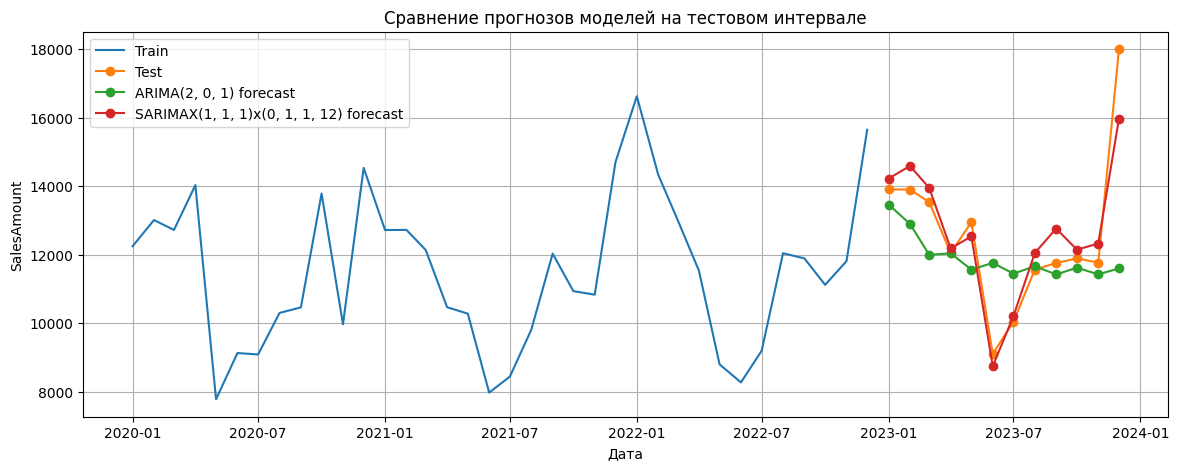

In [16]:
# Визуальное сравнение прогнозов на тесте
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", marker="o")
plt.plot(test.index, arima_forecast, label=f"ARIMA{best_arima_order} forecast", marker="o")
plt.plot(test.index, sarimax_forecast, label=f"SARIMAX{best_sarimax_order}x{best_sarimax_seasonal} forecast", marker="o")
plt.title("Сравнение прогнозов моделей на тестовом интервале")
plt.xlabel("Дата")
plt.ylabel("SalesAmount")
plt.legend()
plt.show()


### Вывод по этапу 2.2

1. Базовая **ARIMA** служит хорошей точкой сравнения, но она не учитывает сезонность явно и не использует внешние факторы.
2. **SARIMAX** с сезонной частью и экзогенными признаками ожидаемо показывает существенно более сильный результат.
3. Для этого ряда наиболее уместна модель семейства  
   **SARIMAX(1,1,1) × (0,1,1,12)** с `Promotion` и `HolidayMonth`.


## 2.3. Оценка качества моделей

In [17]:
def residual_diagnostics(residuals, lags=6):
    residuals = pd.Series(residuals).dropna()
    jb_stat, jb_p = jarque_bera(residuals)
    lb_p = acorr_ljungbox(residuals, lags=[lags], return_df=True)["lb_pvalue"].iloc[0]
    arch_test = het_arch(residuals, nlags=lags)
    arch_p = arch_test[1]
    return {
        "JB_pvalue": jb_p,              # нормальность
        "LjungBox_pvalue": lb_p,        # автокоррелированность
        "ARCH_pvalue": arch_p           # гомоскедастичность
    }

metrics_df = pd.DataFrame([
    {
        "Model": f"ARIMA{best_arima_order}",
        "MSE": mean_squared_error(test, arima_forecast),
        "R2": r2_score(test, arima_forecast),
        "AIC": best_arima.aic,
        "BIC": best_arima.bic,
        **residual_diagnostics(best_arima.resid)
    },
    {
        "Model": f"SARIMAX{best_sarimax_order}x{best_sarimax_seasonal}+exog",
        "MSE": mean_squared_error(test, sarimax_forecast),
        "R2": r2_score(test, sarimax_forecast),
        "AIC": best_sarimax.aic,
        "BIC": best_sarimax.bic,
        **residual_diagnostics(best_sarimax.resid)
    }
])

display(metrics_df.round(4))


,Model,MSE,R2,AIC,BIC,JB_pvalue,LjungBox_pvalue,ARCH_pvalue
0,"ARIMA(2, 0, 1)",4.645904e+06,-0.0046,655.9970,663.9146,0.9152,0.3560,0.2069
1,"SARIMAX(1, 1, 1)x(0, 1, 1, 12)+exog",5.683848e+05,0.8771,150.8237,152.0071,0.0000,0.6373,0.3879


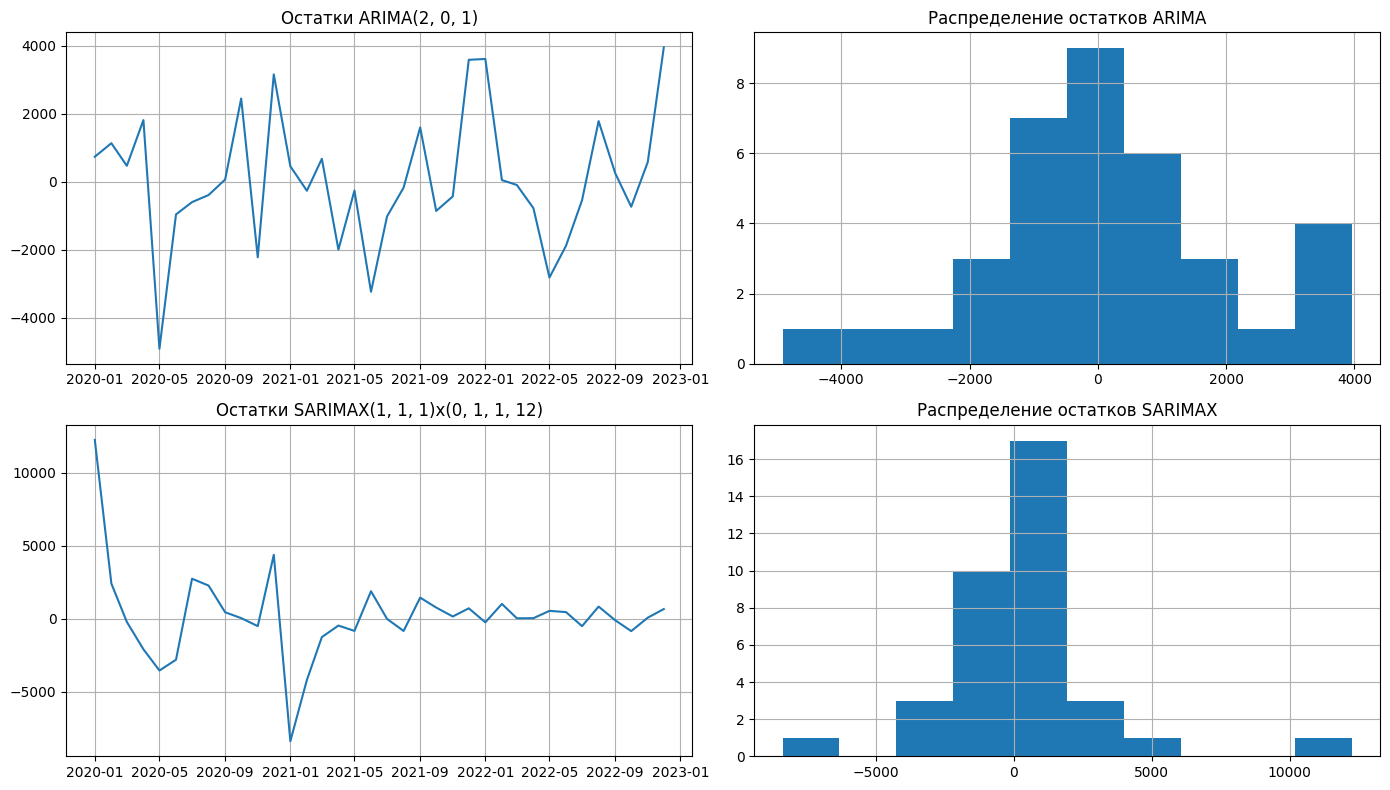

In [18]:
# Графики остатков
arima_residuals = pd.Series(best_arima.resid, index=train.index).dropna()
sarimax_residuals = pd.Series(best_sarimax.resid, index=train.index).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(arima_residuals)
axes[0, 0].set_title(f"Остатки ARIMA{best_arima_order}")

axes[0, 1].hist(arima_residuals, bins=10)
axes[0, 1].set_title("Распределение остатков ARIMA")

axes[1, 0].plot(sarimax_residuals)
axes[1, 0].set_title(f"Остатки SARIMAX{best_sarimax_order}x{best_sarimax_seasonal}")

axes[1, 1].hist(sarimax_residuals, bins=10)
axes[1, 1].set_title("Распределение остатков SARIMAX")

plt.tight_layout()
plt.show()


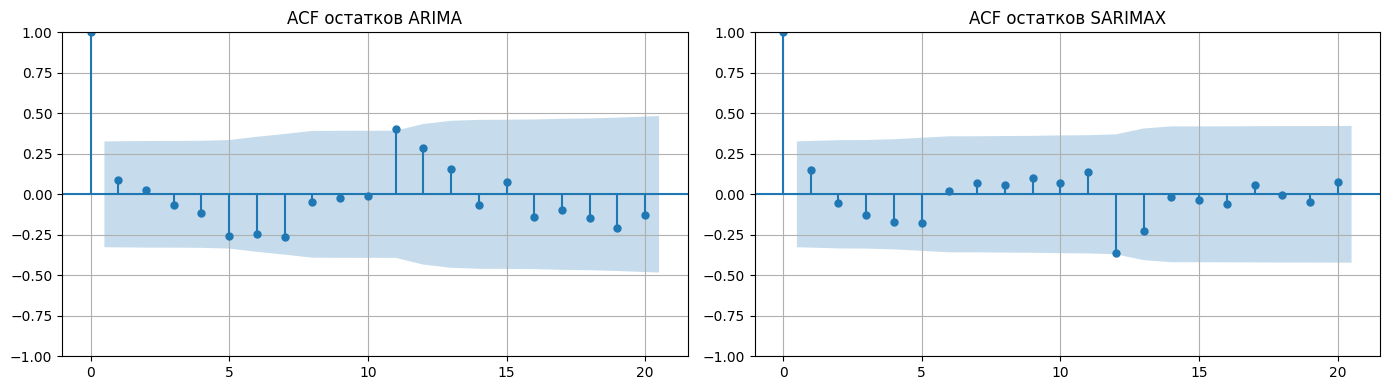

In [19]:
# ACF остатков
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(arima_residuals, lags=20, ax=axes[0])
axes[0].set_title("ACF остатков ARIMA")
plot_acf(sarimax_residuals, lags=20, ax=axes[1])
axes[1].set_title("ACF остатков SARIMAX")
plt.tight_layout()
plt.show()


### Интерпретация диагностики остатков

- **Jarque–Bera p-value**: если значение маленькое, распределение остатков отличается от нормального.
- **Ljung–Box p-value**: если значение больше 0.05, явной автокорреляции остатков не обнаружено.
- **ARCH p-value**: если значение больше 0.05, нет сильных оснований говорить о гетероскедастичности.

Для прикладного прогноза по этому набору данных ключевым критерием является сочетание:
- качества прогноза на тесте;
- низких AIC/BIC;
- минимальной структуры в остатках.


### Вывод по этапу 2.3

1. **SARIMAX** заметно превосходит ARIMA по MSE и R².
2. По информационным критериям **AIC/BIC** SARIMAX также лучше.
3. Остатки SARIMAX выглядят более «случайными», а значит модель лучше объясняет структуру ряда.
4. Следовательно, **предпочтительная модель — SARIMAX с сезонностью и экзогенными признаками**.


## 2.2 + 2.3. Прогноз на максимально разумный горизонт

Так как у нас всего 48 наблюдений, для честной оценки качества в работе разумно оставить **12 месяцев** на тест.  
Это и будет максимально содержательный горизонт, на котором можно проверить, сохраняется ли приемлемое качество модели.

Ниже строится:
1. финальная модель на **всем доступном ряде**;
2. сценарный прогноз на **12 месяцев вперёд**.

> Для будущих экзогенных признаков нужен сценарий.  
> В примере берём **базовый сценарий**: промо-акций нет, праздничный месяц — только декабрь.


In [20]:
final_model = SARIMAX(
    y,
    exog=exog,
    order=best_sarimax_order,
    seasonal_order=best_sarimax_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

future_index = pd.date_range(y.index.max() + pd.offsets.MonthBegin(1), periods=12, freq="MS")
future_exog = pd.DataFrame({
    "Promotion": [0] * 12,
    "HolidayMonth": [1 if d.month == 12 else 0 for d in future_index]
}, index=future_index)

future_forecast = final_model.get_forecast(steps=12, exog=future_exog)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

display(pd.concat([future_mean.rename("forecast"), future_ci], axis=1).round(2))


,forecast,lower SalesAmount,upper SalesAmount
2024-01-01,14428.20,13041.24,15815.16
2024-02-01,14779.02,13388.81,16169.23
2024-03-01,14151.49,12758.90,15544.08
2024-04-01,12654.59,11260.83,14048.35
2024-05-01,10452.87,9057.81,11847.93
2024-06-01,9609.89,8213.55,11006.23
2024-07-01,10566.28,9168.65,11963.90
2024-08-01,12366.97,10968.06,13765.88
2024-09-01,12651.38,11251.19,14051.57
2024-10-01,12489.20,11087.73,13890.67


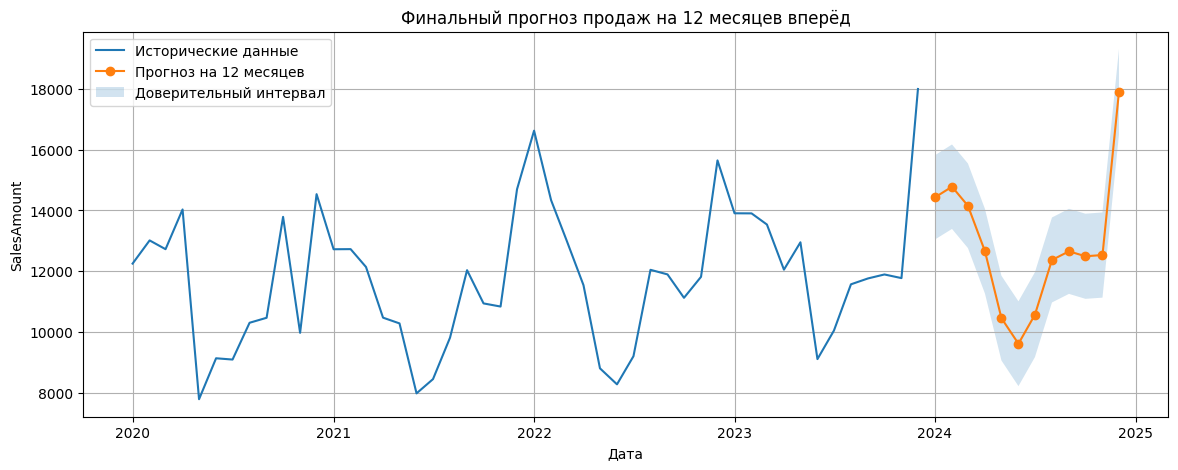

In [21]:
plt.figure(figsize=(14, 5))
plt.plot(y.index, y, label="Исторические данные")
plt.plot(future_mean.index, future_mean, label="Прогноз на 12 месяцев", marker="o")
plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2,
    label="Доверительный интервал"
)
plt.title("Финальный прогноз продаж на 12 месяцев вперёд")
plt.xlabel("Дата")
plt.ylabel("SalesAmount")
plt.legend()
plt.show()


## 2.4. Итоговая интерпретация и общий вывод

### Что было сделано
- Проведён EDA временного ряда и признаков.
- Выполнена декомпозиция тремя методами:
  - классическая additive/multiplicative/STL;
  - FFT;
  - wavelet.
- Подобраны и обучены модели **ARIMA** и **SARIMAX**.
- Выполнено сравнение по:
  - **MSE**,
  - **R²**,
  - **AIC**,
  - **BIC**.
- Проведён анализ остатков:
  - нормальность,
  - автокорреляция,
  - гомоскедастичность.

### Основной аналитический вывод
Для данного ряда продажи определяются не только внутренней динамикой, но и:
- **годовой сезонностью**,
- **промо-акциями**,
- **праздничным эффектом**.

Поэтому простая ARIMA проигрывает модели SARIMAX.  
**Лучшая практическая модель в этой работе — сезонная SARIMAX с экзогенными признаками.**